#### Data : Fashion MNIST (Keras)

In [1]:
# Data 가져오기와 데이터 분류

from tensorflow import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

# 정규화
train_scaled = train_input / 255.0

# train과 valid data 생성
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size= 0.2,
        random_state=42
    )

In [11]:
# Model 생성 함수

def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Flatten(input_shape =(28, 28)))       # fashion MNIST 이미지 28*28 / 입력층
    model.add(keras.layers.Dense(100, activation='relu'))        # hidden layer 1
    
    # 추가 은닉층 필요하면 넣는거
    if a_layer :
        model.add(a_layer)

    model.add(keras.layers.Dense(10, activation='softmax'))     # 출력층
    return model

In [12]:
# 모델 구성 및 Summary
model = model_fn()
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 훈련 및 과정에 대한 history 보기
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8134 - loss: 0.5306
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8574 - loss: 0.3927
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8724 - loss: 0.3544
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8805 - loss: 0.3318
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8861 - loss: 0.3166


In [14]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

#### 손실(loss) 곡선

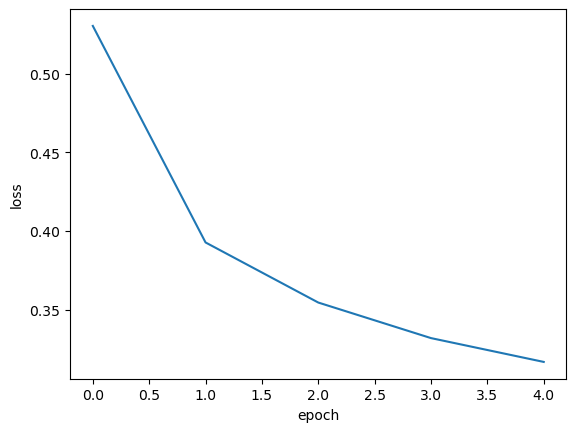

In [ ]:
import matplotlib.pyplot as plt

# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

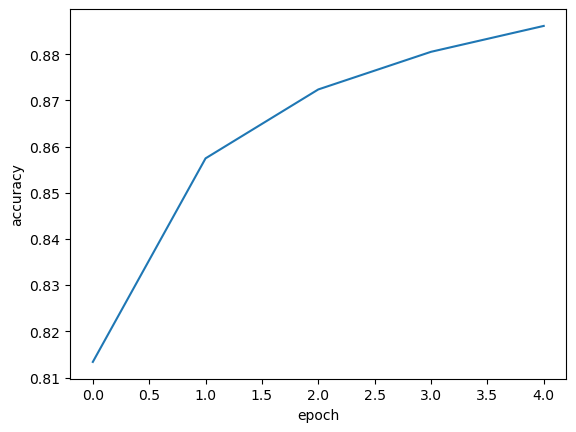

In [ ]:
# epoch vs. accuracy 그래프
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

> epochs를 늘리면 정확도가 올라가고 손실이 떨어질 듯 (가설)

----
#### 반복 훈련의 증가 (epochs 증가) : 가설증명

In [20]:
model = model_fn()
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

history = model.fit(train_scaled, train_target, epochs = 20)        # epochs 증가 5 -> 20

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8124 - loss: 0.5346
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8583 - loss: 0.3933
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8704 - loss: 0.3558
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8804 - loss: 0.3333
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8856 - loss: 0.3180
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8908 - loss: 0.3033
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8956 - loss: 0.2941
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8981 - loss: 0.2864
Epoch 9/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9012 - loss: 0.2784
Epoch 10/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9032 - loss: 0.2713
Epoch 11/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9058 - loss: 0.2642
Epoch 12/20
1500/1500 ━━━━━━━━━━━━━━━━━━━

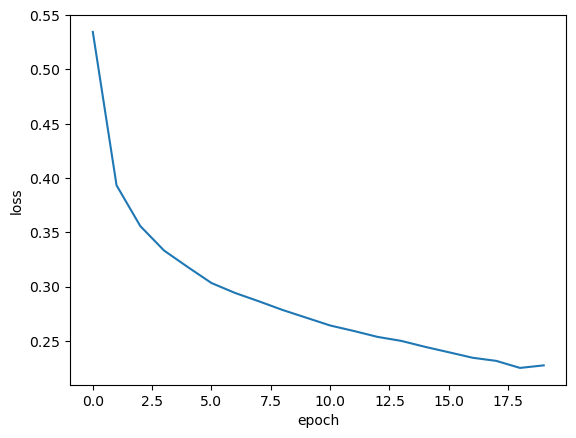

In [21]:
# history의 시각화
# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

----
#### 검증 손실
: 검증세트 대한 정확도를 파악

In [22]:
model = model_fn()
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(train_scaled, train_target, epochs = 20, validation_data=(val_scaled, val_target))

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8141 - loss: 0.5299 - val_accuracy: 0.8517 - val_loss: 0.4099
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8589 - loss: 0.3922 - val_accuracy: 0.8621 - val_loss: 0.3828
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8723 - loss: 0.3542 - val_accuracy: 0.8684 - val_loss: 0.3701
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8792 - loss: 0.3351 - val_accuracy: 0.8670 - val_loss: 0.3922
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8861 - loss: 0.3184 - val_accuracy: 0.8692 - val_loss: 0.3858
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8905 - loss: 0.3037 - val_accuracy: 0.8802 - val_loss: 0.3523
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8932 - loss: 0.2963 - val_accuracy: 0.8802 - val_loss: 0.3681
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8971 - loss: 0.2868 - val_accurac

In [ ]:
# fit 과정에 validation_data를 주면 'val_accuracy', 'val_loss' 같이 나옴
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

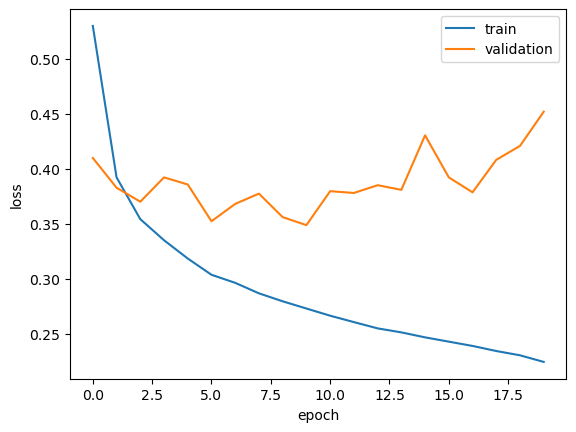

In [25]:
# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'validation'])
plt.show()

> 훈련 세트는 epochs가 증가함에 따라 손실이 떨어지고 있으나, 검증 세트는 epochs 초반에는 떨어지나 진행할 수록 loss 증가 <br>
이 모델은 훈련세트의 정확도가 높아 좋지만 검증세트에는 적합하지 않은 과대적합 모델이다.

----
#### Optimizer

In [26]:
model = model_fn()
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(train_scaled, train_target, epochs = 20, validation_data=(val_scaled, val_target))

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8171 - loss: 0.5228 - val_accuracy: 0.8536 - val_loss: 0.4129
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8616 - loss: 0.3897 - val_accuracy: 0.8531 - val_loss: 0.4037
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8736 - loss: 0.3498 - val_accuracy: 0.8667 - val_loss: 0.3619
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8829 - loss: 0.3239 - val_accuracy: 0.8767 - val_loss: 0.3456
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8890 - loss: 0.3048 - val_accuracy: 0.8805 - val_loss: 0.3342
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8942 - loss: 0.2881 - val_accuracy: 0.8819 - val_loss: 0.3299
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8981 - loss: 0.2763 - val_accuracy: 0.8870 - val_loss: 0.3206
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9016 - loss: 0.2653 - val_accurac

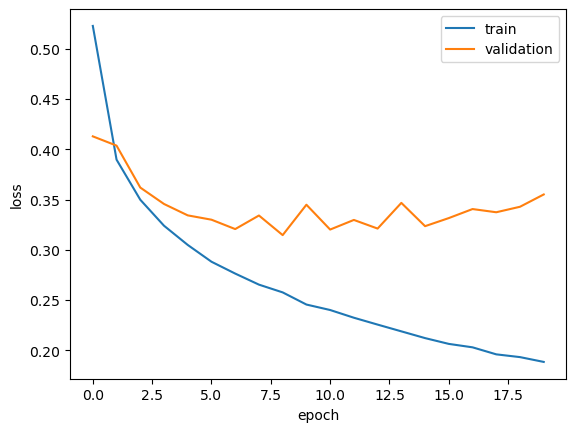

In [27]:
# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'validation'])
plt.show()

optimizer(최적화 알고리즘)을 사용해서 train / valid 손실율이 좀 더 비슷해지고 valid의 손실율이 안정화 되었으나 아직 과대적합

----
#### Dropout
: 훈련 시 각 데이터를 처리할 때 데이터의 갯수를 랜덤으로 줄인다.

In [ ]:
# model에 dropout을 추가
model = model_fn(keras.layers.Dropout(0.3))         # 0.3 : 30%는 제외 / dropout layer 추가
model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(train_scaled, train_target, epochs = 20, validation_data=(val_scaled, val_target))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7923 - loss: 0.5908 - val_accuracy: 0.8488 - val_loss: 0.4201
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8415 - loss: 0.4405 - val_accuracy: 0.8642 - val_loss: 0.3825
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8544 - loss: 0.4026 - val_accuracy: 0.8643 - val_loss: 0.3703
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8610 - loss: 0.3815 - val_accuracy: 0.8693 - val_loss: 0.3610
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8661 - loss: 0.3656 - val_accuracy: 0.8702 - val_loss: 0.3469
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8712 - loss: 0.3520 - val_accuracy: 0.8721 - val_loss: 0.3409
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8731 - loss: 0.3410 - val_accuracy: 0.8778 - val_loss: 0.3377
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8754 - loss: 0.3354 - 

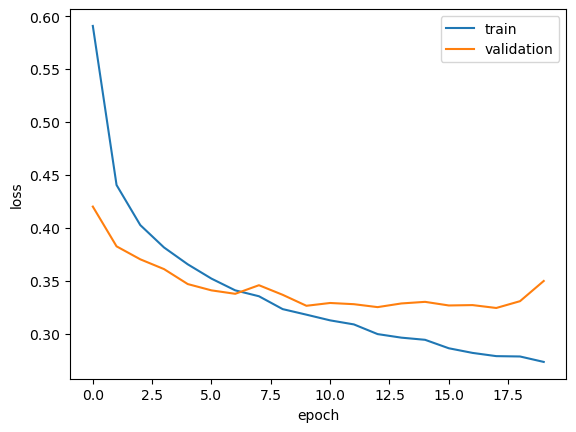

In [30]:
# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'validation'])
plt.show()

epochs = 9 인 경우 train과 valid의 차이가 적은 듯 <br>
-> 기본적으로 훈련세트의 손실이 검증세트보다 적게 나오는 epochs를 선택

In [31]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(train_scaled, train_target, epochs = 9, validation_data=(val_scaled, val_target))

Epoch 1/9


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7937 - loss: 0.5902 - val_accuracy: 0.8282 - val_loss: 0.4624
Epoch 2/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8412 - loss: 0.4428 - val_accuracy: 0.8543 - val_loss: 0.3973
Epoch 3/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8539 - loss: 0.4052 - val_accuracy: 0.8670 - val_loss: 0.3680
Epoch 4/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8614 - loss: 0.3824 - val_accuracy: 0.8708 - val_loss: 0.3581
Epoch 5/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8659 - loss: 0.3660 - val_accuracy: 0.8751 - val_loss: 0.3418
Epoch 6/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8699 - loss: 0.3547 - val_accuracy: 0.8750 - val_loss: 0.3442
Epoch 7/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8730 - loss: 0.3442 - val_accuracy: 0.8766 - val_loss: 0.3380
Epoch 8/9
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8754 - loss: 0.3377 - val_accuracy: 0.87

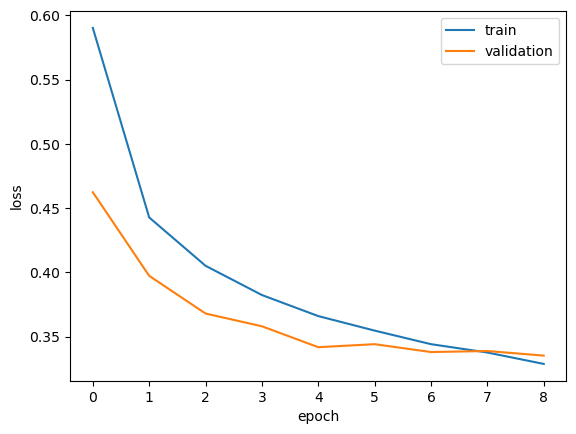

In [32]:
# epoch vs. loss 그래프
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'validation'])
plt.show()

----
#### 모델의 저장과 복원

In [33]:
# 모델의 저장
model.save('../Data/model_fashion.keras')

In [34]:
# 복원
model1 = keras.models.load_model('../Data/model_fashion.keras')

In [35]:
# 사용
model1.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8780 - loss: 0.3353


[0.3352719843387604, 0.878000020980835]

----
#### callbacks
: 훈련 수행 시 손실값이 제일 작은 모델을 저장해준다

In [36]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')

history = model.fit(
    train_scaled,
    train_target,
    epochs = 20,
    validation_data=(val_scaled, val_target),
    callbacks = [checkpoint_cb]    
)

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7941 - loss: 0.5875 - val_accuracy: 0.8432 - val_loss: 0.4293
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8438 - loss: 0.4381 - val_accuracy: 0.8512 - val_loss: 0.4032
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8540 - loss: 0.4045 - val_accuracy: 0.8608 - val_loss: 0.3762
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8587 - loss: 0.3833 - val_accuracy: 0.8692 - val_loss: 0.3563
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8667 - loss: 0.3643 - val_accuracy: 0.8744 - val_loss: 0.3494
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8682 - loss: 0.3545 - val_accuracy: 0.8765 - val_loss: 0.3352
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8739 - loss: 0.3405 - val_accuracy: 0.8801 - val_loss: 0.3319
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8757 - loss: 0.3337 - val_accurac

In [37]:
# 저장된 best_model 호출
model2 = keras.models.load_model('../Data/best_model.keras')

In [38]:
model2.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8874 - loss: 0.3192


[0.31924059987068176, 0.887416660785675]

----
#### Eerly Stopping(조기종료)
: Callbacks를 끝까지 기다리는 것이 아니고 patience(Hyper parameter)를 선정하여 한계값을 정해 실행

In [ ]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
                        '../Data/best_model.keras',
                        save_best_only= True                            # val_loss가 제일 적은 epochs의 모델저장
)

early_stopping_cb = keras.callbacks.EarlyStopping(
                        patience=2,
                        restore_best_weights=True
)

history = model.fit(
    train_scaled,
    train_target,
    epochs = 20,
    validation_data=(val_scaled, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]    
)

Epoch 1/20


c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7964 - loss: 0.5791 - val_accuracy: 0.8468 - val_loss: 0.4237
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8414 - loss: 0.4374 - val_accuracy: 0.8565 - val_loss: 0.3881
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8530 - loss: 0.4007 - val_accuracy: 0.8622 - val_loss: 0.3724
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8611 - loss: 0.3815 - val_accuracy: 0.8683 - val_loss: 0.3581
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8664 - loss: 0.3660 - val_accuracy: 0.8686 - val_loss: 0.3530
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8692 - loss: 0.3521 - val_accuracy: 0.8773 - val_loss: 0.3382
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8722 - loss: 0.3443 - val_accuracy: 0.8771 - val_loss: 0.3366
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8764 - loss: 0.3321 - val_accurac

In [47]:
# 몇번째 epoch에서 stop 되었는가?
# stopped_epoch : 7 -> 8번째에서 멈춤 -> patience가 2니까 epochs = 6이 best
early_stopping_cb.stopped_epoch

9

In [48]:
model2 = keras.models.load_model('../Data/best_model.keras')
model2.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)                 │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 100)                 │          78,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [50]:
model2.optimizer.get_config()

{'name': 'adam_5',
 'learning_rate': 0.0010000000474974513,
 'weight_decay': None,
 'clipnorm': None,
 'global_clipnorm': None,
 'clipvalue': None,
 'use_ema': False,
 'ema_momentum': 0.99,
 'ema_overwrite_frequency': None,
 'loss_scale_factor': None,
 'gradient_accumulation_steps': None,
 'beta_1': 0.9,
 'beta_2': 0.999,
 'epsilon': 1e-07,
 'amsgrad': False}

In [49]:
model2.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8805 - loss: 0.3282


[0.3282032012939453, 0.8805000185966492]